# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import itertools
import string
import time
from pathlib import Path
from typing import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM Pride in Preduice
seq_lengths = (1, 6)
seq_chars = string.ascii_uppercase
instruction_set_len = len(seq_chars)
total_size = sum(instruction_set_len**n for n in seq_lengths)
print(f'{total_size:=,} of {instruction_set_len:=} instructions at {seq_lengths=}')

seq_products = itertools.chain(
    *(itertools.product(string.ascii_uppercase, repeat=n)
      for n in seq_lengths)
)
filter_seq_products = (
    f'{i:08d}-' + ''.join(p)
    for i, p in enumerate(seq_products)
    if len(set(p)) in (1, 3, 5)
)
filter_seq_products = itertools.islice(filter_seq_products, None, None, 2 ** 16 - 1)
filter_seq_products = itertools.islice(filter_seq_products, None, 6000)


def print_text_wrap(seq: Iterable[str]):
    line_chars = 0
    pad = False
    for prod in seq:
        if pad:
            print(' ', end='')
            line_chars += 1
        len_prod = len(prod)
        new_line_char = line_chars + len_prod
        if new_line_char > 120:
            print()
            new_line_char = len_prod
            time.sleep(0.1)
        print(prod, end='')
        line_chars = new_line_char
        pad = True


print_text_wrap(filter_seq_products)

308,915,802 of 26 instructions at seq_lengths=(1, 6)
00000000-A 00104035-AAFXWJ 00195804-AALDPY 00286994-AAQING 00378185-AAVNKP 00469956-ABATEG 00633575-ABKBFH 
00822751-ABUVBH 00972864-ACDJCW 01162065-ACOCZV 01352525-ACYYTF 01502299-ADHMHT 01691461-ADSGDF 01862649-AEBZJJ 
02031781-AELPOL 02220894-AEWJIA 02382548-AFFOLM 02561207-AFPSSZ 02747047-AGAHQR 02901502-AGJCDG 03090702-AGTWAE 
03259750-AHDMCA 03430934-AHNFIA 03620136-AHXZFA 03789206-AIHPHS 03960211-AIRIGV 04130522-AJBAFG 04299665-AJKQKT 
04488832-AJVKGK 04658992-AKFBZA 04829150-AKOTRO 05018260-AKZNLA 05188409-ALJFDF 05358593-ALSWWT 05527683-AMCNAF 
05706293-AMMRFV 05888030-AMXABS 06057116-ANGQFA 06228360-ANQJNI 06407078-AOANXC 06586571-AOKTKR 06757810-AOUMSU 
06926844-APECUC 07116004-APOWPM 07286870-APYPJG 07456319-AQIGAN 07626519-AQRXUR 07796663-ARBPMR 07985779-ARMJGJ 
08155539-ARWAJP 08325849-ASFSHZ 08515247-ASQMMN 08684193-ATACKL 08854482-ATJUIA 09030062-ATTUBC 09194520-AUDDIK 
09383936-AUNXNQ 09555179-AUXQVX 09724214-AVHGXG 

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

34

In [4]:
reports_paths.sort_values(ascending=False).head()

32    data/cash_app_report_1787932141636.csv
30    data/cash_app_report_1787843145215.csv
11    data/cash_app_report_1787418778201.csv
12    data/cash_app_report_1786713122466.csv
8     data/cash_app_report_1786299917965.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1787932141636.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-08-28 11:48:40 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,AMZN,$266.47,0.03752,COMPLETE,$10 Purchase of Amazon,NaN,Cash Balance
1,2026-08-28 11:10:39 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,F,$13.94,0.71747,COMPLETE,$10 Purchase of Ford Motor,NaN,Cash Balance
2,2026-08-28 09:30:21 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,SG,$6.82,1.46642,COMPLETE,$10 Purchase of Sweetgreen,NaN,Cash Balance
3,2026-08-28 09:30:19 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,META,$571.30,0.01750,COMPLETE,$10 Purchase of Meta,NaN,Cash Balance
4,2026-08-28 09:30:18 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,SAIA,$359.28,0.02783,COMPLETE,$10 Purchase of Saia,NaN,Cash Balance
5,2026-08-28 09:30:13 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,DDOG,$240.22,0.04162,COMPLETE,$10 Purchase of Datadog,NaN,Cash Balance
6,2026-08-28 09:30:12 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,LMT,$567.97,0.01760,COMPLETE,$10 Purchase of Lockheed Martin,NaN,Cash Balance
7,2026-08-28 09:30:12 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,DOW,$30.65,0.32626,COMPLETE,$10 Purchase of Dow,NaN,Cash Balance
8,2026-08-28 09:30:11 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,OLN,$17.52,0.57077,COMPLETE,$10 Purchase of Olin,NaN,Cash Balance
9,2026-08-28 09:30:07 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,RTX,$212.73,0.04700,COMPLETE,$10 Purchase of RTX,NaN,Cash Balance


In [7]:
data_raw.tail()

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
822,2025-09-16 19:42:27 EDT,#D-QVL3M3DK,P2P,USD,$70.00,$0.00,$70.00,NaN,NaN,NaN,COMPLETE,Camping,Full Name,Cash Balance
823,2025-08-22 12:07:20 EDT,NaN,Account Notifications,USD,$0.00,NaN,$0.00,NaN,NaN,NaN,COMPLETE,New device login,NaN,Cash Balance
824,2022-11-28 10:28:53 EST,7bg2rwg,P2P,USD,-$20.00,$0.00,-$20.00,NaN,NaN,NaN,COMPLETE,baby gift,Mark Brown,Wells Fargo Bank
825,2022-10-07 12:05:33 EDT,q3ryf2r,P2P,USD,-$10.00,$0.00,-$10.00,NaN,NaN,NaN,COMPLETE,Baby gift contribution,Ilana Reeves,Wells Fargo Bank
826,2021-08-04 13:53:19 EDT,b1aawxk,P2P,USD,-$15.00,$0.00,-$15.00,NaN,NaN,NaN,COMPLETE,lieberman baby gift,Mark Brown,Wells Fargo Bank


In [8]:
data_raw.shape

(827, 14)

In [9]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
420,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
204,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
291,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
176,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
205,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
289,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
255,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
355,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
209,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
121,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [10]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,642.0,0.2,0.0,0.0,0.1,0.2,4.5


In [11]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
650,2026-06-03 07:23:18+00:00,100.0,100.0,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
603,2026-06-03 13:30:10+00:00,-1.0,-1.0,418.42,0.00238,0.0,TSLA,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Tesla,NaN
508,2026-06-03 19:20:29+00:00,-10.0,-10.0,428.31,0.02334,0.0,MSFT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Microsoft,NaN
451,2026-06-04 13:30:04+00:00,-10.0,-10.0,21.01,0.47596,0.0,TTD,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Trade Desk,NaN
446,2026-06-04 13:30:12+00:00,-10.0,-10.0,90.81,0.11012,0.0,CRCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Circle,NaN
361,2026-06-16 13:30:08+00:00,-5.0,-5.0,57.42,0.08707,0.0,TSN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Tyson Foods,NaN
342,2026-06-16 13:30:16+00:00,-5.0,-5.0,5.13,0.97465,0.0,HTZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Hertz,NaN
309,2026-06-18 14:09:47+00:00,-5.0,-5.0,572.17,0.00873,0.0,META,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Meta,NaN
291,2026-06-18 17:14:33+00:00,8.0,8.0,163.24,0.04900,0.0,COIN,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$8 Sale of Coinbase,NaN
107,2026-07-16 13:30:04+00:00,-10.0,-10.0,116.54,0.08580,0.0,UAL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of United Continental Holdings,NaN


In [12]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
141,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
820,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
821,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
822,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
824,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
825,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
826,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


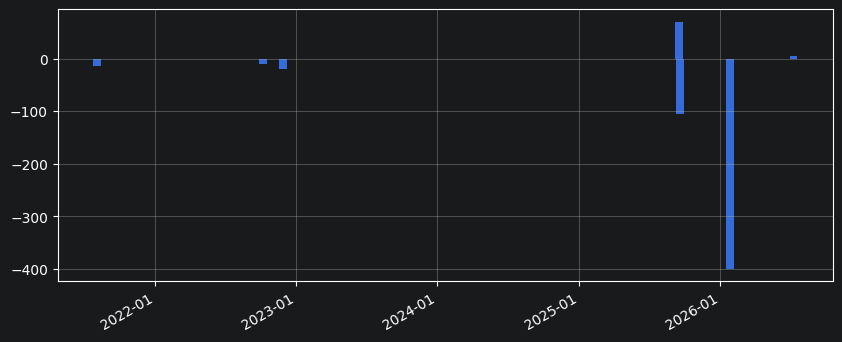

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [14]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,827.00,827.00,642.00,827.00,824.00
mean,0.04,0.05,3831.48,0.13,-0.01
std,35.69,35.69,15482.30,0.31,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,57.55,0.00,0.00
50%,-10.00,-10.00,129.06,0.04,0.00
75%,0.04,0.04,300.64,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [15]:
data.nunique().sort_values(ascending=False)

date            647
asset_price     630
asset_amount    626
notes           470
asset_type      187
amount           71
net_amount       70
trans_type       11
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [16]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    558
Stock Dividends               87
Deposits                      73
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [17]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,558,10.37,1.00,10.00,10.00,10.00,50.00
Stock Dividends,87,0.12,0.01,0.04,0.09,0.16,0.48
Deposits,73,89.53,1.00,100.00,100.00,100.00,200.00
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      16
JPM      15
ORCL     14
AMZN     13
META     13
WFC      12
VGLT     10
DELL     10
NFLX     10
V        10
MCD      10
PZZA     10
DOW       9
VMBS      9
GOOGL     9
VONV      9
VOO       8
MSFT      8
GOOG      8
UBER      8
PLTR      7
AAPL      7
DAL       7
INTU      7
Name: count, dtype: int64

Text(0, 0.5, 'Count')

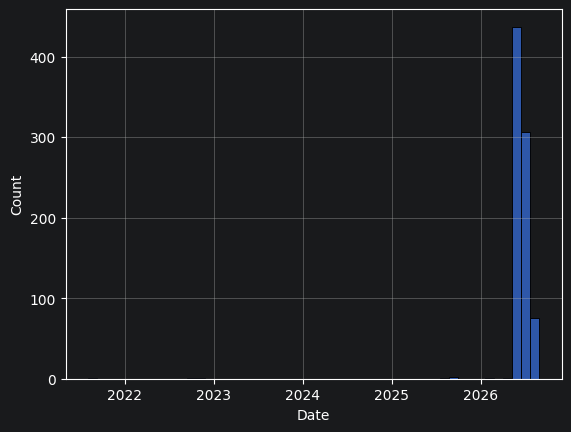

In [19]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [20]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-24,2026-05-27,2026-05-30,2026-06-03,2026-06-08,2026-07-01,2026-07-17,2026-08-05,2026-08-28


In [21]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,16,-201.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,15,-89.64,"(-25.0, -10.0, -5.0, 0.36, 10.0, 20.0)",6
ORCL,14,-109.73,"(-10.0, -5.0, 0.27)",3
AMZN,13,-231.00,"(-50.0, -25.0, -10.0, -1.0)",4
META,13,-95.95,"(-10.0, -5.0, -1.0, 0.05)",4
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4
NFLX,10,-55.00,"(-10.0, -5.0, 10.0)",3


In [22]:
data['currency'].value_counts()

currency
USD    827
Name: count, dtype: int64

In [23]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    558
Stock Dividends               87
Deposits                      73
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [24]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Investing,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,,
total,24,10,2,558,87,50,731
BTC,24,10,0,0,0,0,34
XYZ,0,0,0,15,0,1,16
JPM,0,0,0,12,1,2,15
ORCL,0,0,0,13,1,0,14
META,0,0,0,12,1,0,13
AMZN,0,0,0,13,0,0,13
WFC,0,0,0,10,0,2,12
MCD,0,0,0,9,1,0,10


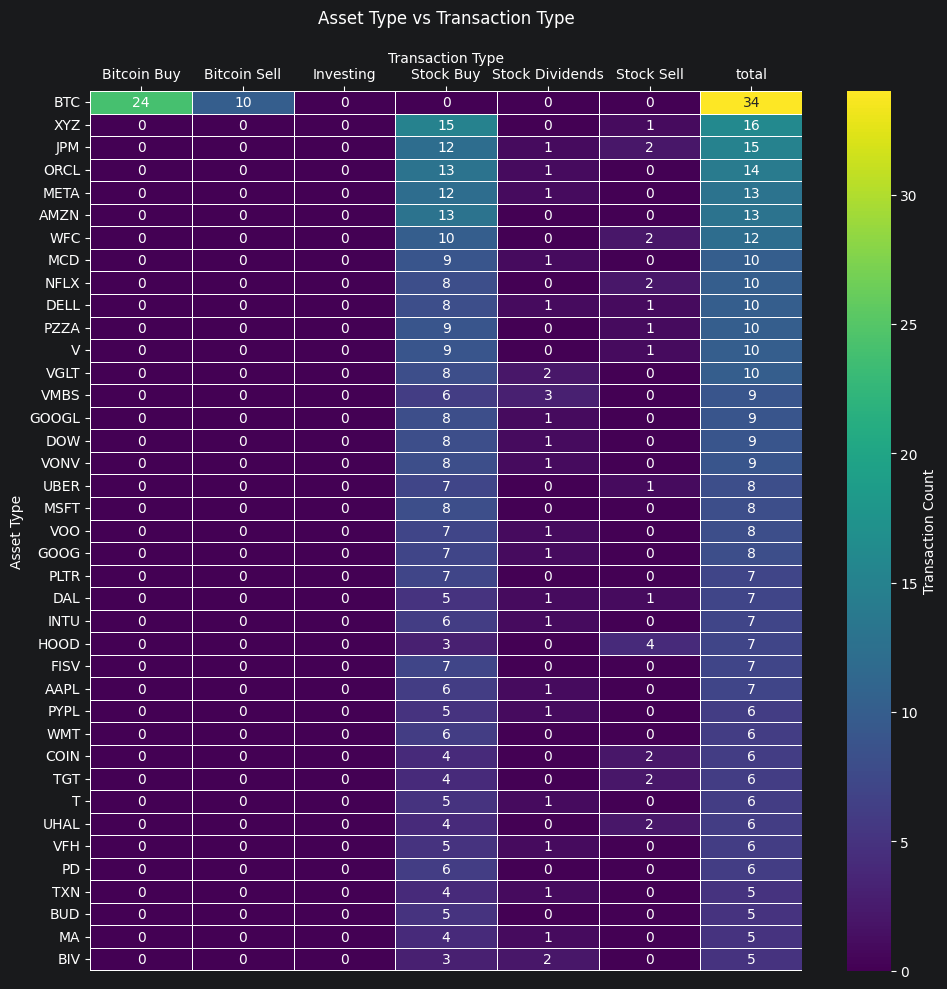

In [25]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [26]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
99,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
123,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
129,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
150,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
162,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


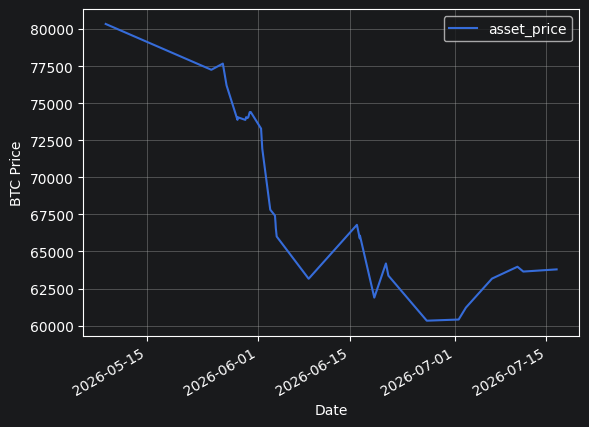

In [27]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [28]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [29]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [30]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [31]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [32]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [33]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

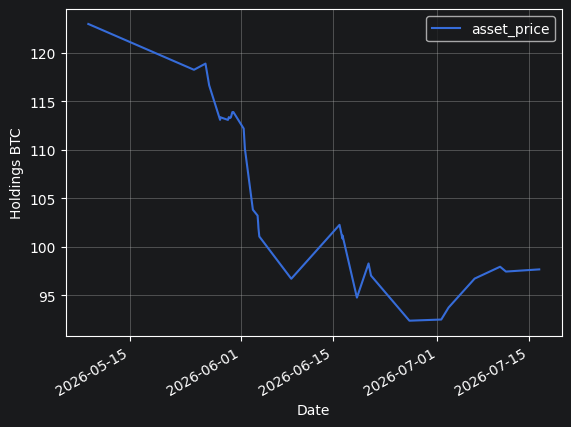

In [34]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [35]:
data_btc['asset_price'] * data_btc['asset_amount']

99      8.999780
123     9.999987
129     9.999926
150     9.999928
162    20.000229
190     9.800290
227     4.900090
282    10.000046
284     4.899747
293    19.999846
375     5.000156
376     4.999899
379     4.900240
415    19.999798
495     9.799846
522     9.800287
546     0.980144
643     9.800221
654     0.979969
671     9.799652
729     4.900136
731     9.799865
734     4.900112
735     9.799903
739     9.799965
743    24.500200
750    24.499951
754    24.500084
773     9.799731
777     9.800031
800    24.499991
817     9.799898
818     4.900356
819     9.799819
dtype: float64

In [36]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
70,2026-07-27 13:30:03+00:00,-10.0,-10.0,78.88,0.12677,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
78,2026-07-21 13:33:10+00:00,-10.0,-10.0,79.31,0.12608,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
145,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
226,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
255,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
337,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
382,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
430,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
506,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
518,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


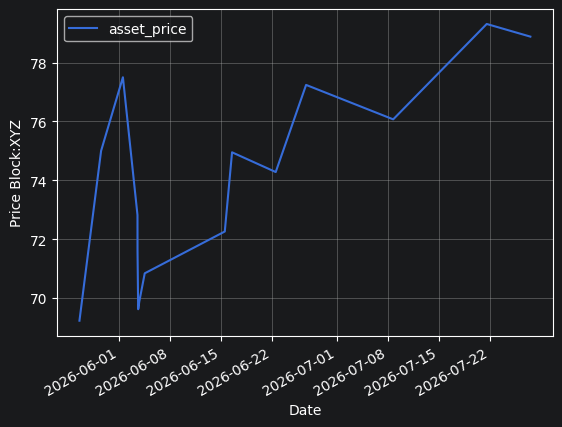

In [37]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [38]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     16
JPM     15
ORCL    14
AMZN    13
        ..
OLN      1
VGT      1
SNAP     1
SLAB     1
ZG       1
Name: amount, Length: 187, dtype: int64

In [39]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [40]:
data['asset_amount'].describe()

count    827.000000
mean       0.133146
std        0.311480
min        0.000000
25%        0.000152
50%        0.042040
75%        0.127380
max        4.509170
Name: asset_amount, dtype: float64

In [41]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
219,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
292,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
556,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
681,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [42]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 13:53:46+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,31.527923,9.686363,19.992722,0.0,99.663815,0.000000,9.953370,0.000000,0.000000
2026-06-03 19:23:43+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,51.890247,18.724670,27.762524,0.0,131.892037,19.945984,9.953370,0.000000,0.000000
2026-06-03 19:38:07+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-03 19:38:31+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-16 15:45:00+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,81.303113,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-07-01 14:18:18+00:00,51.311805,9.999493,0.000000,8.379889,0.000000,9.999577,20.893584,0.000000,9.042617,30.069556,...,6.113515e+00,58.199610,23.724046,37.761938,0.0,178.314166,42.997334,19.954137,9.999727,9.999925
2026-07-02 17:07:58+00:00,51.311805,9.999493,0.000000,8.379889,0.000000,9.999577,0.000000,0.000000,9.042617,30.069556,...,6.113515e+00,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925
2026-07-10 13:30:21+00:00,0.000000,9.999493,0.000000,18.377823,0.000000,9.999577,0.000000,0.000000,9.042617,30.069556,...,6.113515e+00,58.199610,23.724046,59.104053,0.0,196.334284,52.997013,19.954137,9.999727,9.999925
2026-07-13 13:30:03+00:00,0.000000,9.999493,0.000000,18.377823,0.000000,9.999577,0.000000,0.000000,9.042617,30.069556,...,6.113515e+00,63.199466,23.724046,59.104053,0.0,196.334284,52.997013,19.954137,9.999727,9.999925


In [43]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3765.4971775000004)

In [44]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    241.595026
XYZ     215.214614
JPM     104.538330
VGLT     99.442548
MCD      98.010046
Name: 2026-08-28 15:48:40+00:00, dtype: float64

In [45]:
asset_holding_time_last.tail()

asset_type
RUM     0.000000e+00
GM      0.000000e+00
QCOM    0.000000e+00
WEN    -8.337775e-16
BTC              NaN
Name: 2026-08-28 15:48:40+00:00, dtype: float64

In [46]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['AAPL', 'ACN', 'ADP', 'ALKT', 'ALLY', 'AMX', 'ASML', 'AVGO', 'BBEU',
       'BIV', 'BSV', 'C', 'CAT', 'CG', 'CLX', 'COKE', 'CRM', 'CSCO', 'CVS',
       'CXSE', 'DAL', 'DELL', 'DIS', 'DKS', 'EA', 'EMB', 'FIS', 'GAP', 'GIS',
       'GM', 'GSLC', 'HPQ', 'ILMN', 'INTU', 'JEPI', 'KO', 'KWEB', 'LECO',
       'LEVI', 'MA', 'MS', 'NOBL', 'NTAP', 'NVDA', 'ORCL', 'OWL', 'OXY', 'PNC',
       'POR', 'PSKY', 'QCOM', 'RUM', 'RUN', 'SBUX', 'T', 'TSM', 'TXN', 'VBR',
       'VCSH', 'VDC', 'VFH', 'VHT', 'VNQ', 'VONG', 'VRSN', 'VSS', 'VTEB', 'VZ',
       'XLB'],
      dtype='str', name='asset_type')

In [47]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
666,AAPL,$10 Purchase of Apple
622,AAPL,$10 Purchase of Apple
413,AAPL,$10 Purchase of Apple
263,AAPL,$10 Purchase of Apple
34,AAPL,$0.05 Dividend from Apple
...,...,...
517,VZ,$20 Purchase of Verizon Communications
54,VZ,$0.38 Dividend from Verizon Communications
358,VZ,$5 Purchase of Verizon Communications
244,XLB,$0.04 Dividend from Materials Select Sector SPDR


In [48]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-28 13:30:18+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 13:30:19+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 13:30:21+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 15:10:39+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 15:48:40+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656


In [49]:
asset_price_rel.iloc[-1].describe()

count    1.860000e+02
mean     5.376344e-03
std      8.583877e-03
min     -2.214256e-19
25%      0.000000e+00
50%      2.655664e-03
75%      6.046739e-03
max      6.416019e-02
Name: 2026-08-28 15:48:40+00:00, dtype: float64

In [50]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.064160
XYZ     0.057154
JPM     0.027762
VGLT    0.026409
MCD     0.026028
Name: 2026-08-28 15:48:40+00:00, dtype: float64

In [51]:
asset_price_rel_last.tail()

asset_type
RUM     0.000000e+00
GM      0.000000e+00
QCOM    0.000000e+00
WEN    -2.214256e-19
BTC              NaN
Name: 2026-08-28 15:48:40+00:00, dtype: float64

<Axes: ylabel='Frequency'>

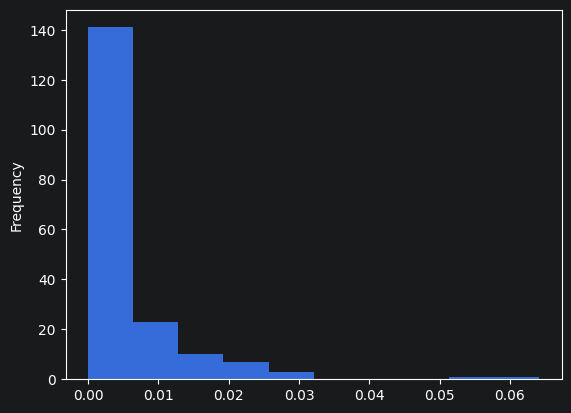

In [52]:
asset_price_rel_last.plot.hist()

In [53]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-28 13:30:18+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 13:30:19+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 13:30:21+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 15:10:39+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656
2026-08-28 15:48:40+00:00,0.0,0.002656,0.0,0.004881,0.0,0.002656,0.0,0.0,0.002401,0.007986,...,-2.214256e-19,0.016784,0.0063,0.015696,0.0,0.057154,0.014074,0.005299,0.002656,0.002656


In [54]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 19:15:32+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-09 16:35:19+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,111.73,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 13:54:31+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-24 13:30:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-08 16:30:32+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:32:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,72.26,NaN,NaN,NaN,NaN
2026-07-10 15:28:47+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 19:15:32+00:00,0.950374,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.075766,0.995338,1.0,1.0
2026-08-17 13:30:23+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.195860,1.124661,0.921293,0.939144,1.0,1.139390,1.075766,0.995338,1.0,1.0
2026-07-09 16:35:19+00:00,1.017280,1.0,0.719207,1.000000,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-06-01 13:30:10+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.000000,1.0,1.0
2026-06-03 13:54:31+00:00,1.021803,1.0,1.000000,1.000000,1.000000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.016277,1.000000,0.955619,1.0,1.034089,1.000000,1.000000,1.0,1.0
2026-06-24 13:30:02+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.072945,1.005550,0.995338,1.0,1.0
2026-06-08 16:30:32+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-15 13:32:07+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-07-10 15:28:47+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

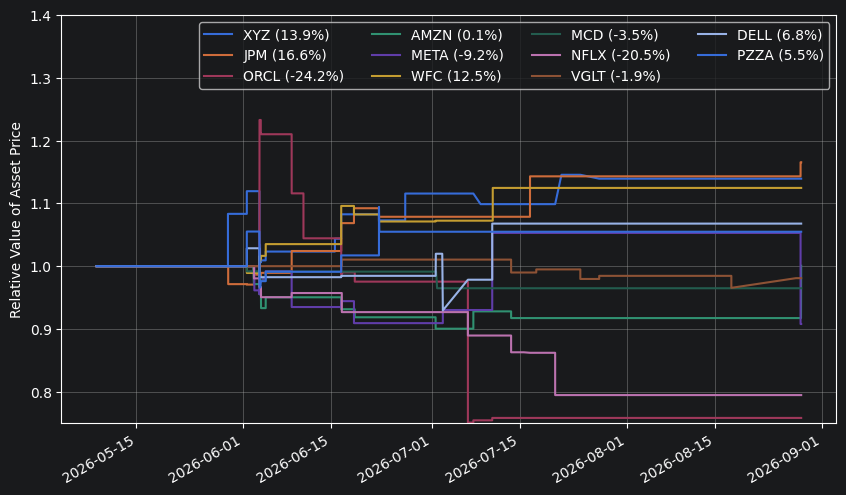

In [56]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(10, 6))
asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=4, loc='upper right')
plt.ylim(0.75, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [57]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.00000
2026-05-24 19:57:02+00:00    1.00000
2026-05-26 14:06:39+00:00    1.00000
2026-05-26 14:09:07+00:00    1.00000
2026-05-27 03:38:54+00:00    1.00000
                              ...   
2026-08-28 13:30:18+00:00    1.13939
2026-08-28 13:30:19+00:00    1.13939
2026-08-28 13:30:21+00:00    1.13939
2026-08-28 15:10:39+00:00    1.13939
2026-08-28 15:48:40+00:00    1.13939
Name: XYZ, Length: 510, dtype: float64

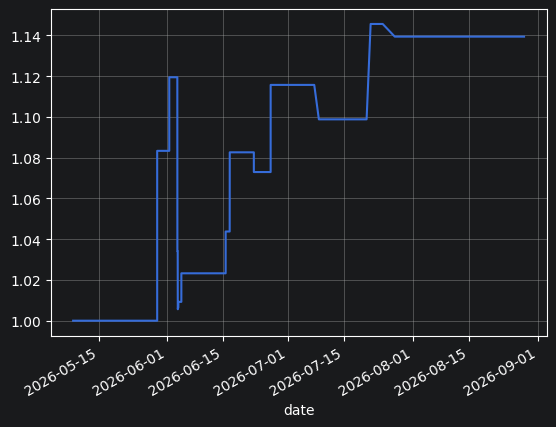

In [58]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [59]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
16,2026-08-28,0.12,SBUX,$0.12 Dividend from Starbucks
18,2026-08-28,0.14,C,$0.14 Dividend from Citigroup
17,2026-08-28,0.14,CLX,$0.14 Dividend from Clorox
23,2026-08-27,0.04,VRSN,$0.04 Dividend from VeriSign
24,2026-08-26,0.21,CG,$0.21 Dividend from The Carlyle Group
...,...,...,...,...
377,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
395,2026-06-15,0.02,GOOG,$0.02 Dividend from Alphabet Inc. Class C
396,2026-06-15,0.02,GOOGL,$0.02 Dividend from Alphabet Inc. Class A
399,2026-06-12,0.05,DOW,$0.05 Dividend from Dow


In [60]:
div_data['amount'].sum()

np.float64(10.12)

In [61]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
53,2026-08-03,0.48,T,$0.48 Dividend from AT&T
54,2026-08-03,0.38,VZ,$0.38 Dividend from Verizon Communications
58,2026-07-31,0.36,JPM,$0.36 Dividend from JPMorgan Chase
45,2026-08-05,0.32,VGLT,$0.32 Dividend from Vanguard Long-Treasury ETF
75,2026-07-22,0.30,AMX,$0.30 Dividend from America Movil
...,...,...,...,...
221,2026-06-30,0.01,AVGO,$0.01 Dividend from Broadcom
246,2026-06-23,0.01,VONG,$0.01 Dividend from Vanguard Russell 1000 Grow...
114,2026-07-15,0.01,TMO,$0.01 Dividend from Thermo Fisher Scientific
40,2026-08-05,0.01,ASML,$0.01 Dividend from ASML Holding


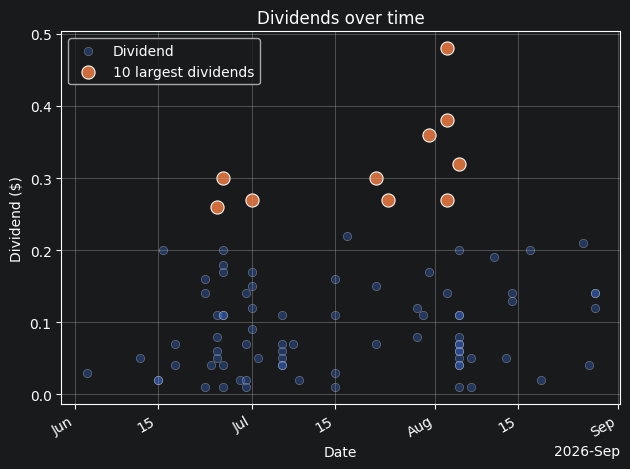

In [62]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [63]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
690,2026-06-01 13:30:23+00:00,-25.00,95.08,$25 Purchase of Vanguard Real Estate ETF,VNQ
246,2026-06-23 04:00:00+00:00,0.01,NaN,$0.01 Dividend from Vanguard Russell 1000 Grow...,VONG
365,2026-06-16 13:30:05+00:00,-5.00,132.21,$5 Purchase of Vanguard Financials ETF,VFH
44,2026-08-05 04:00:00+00:00,0.07,NaN,$0.07 Dividend from Vanguard Short Term Bond ETF,BSV
595,2026-06-03 13:30:13+00:00,-10.00,48.13,$10 Purchase of Vanguard Total International B...,BNDX
638,2026-06-03 13:30:00+00:00,-10.00,76.30,$10 Purchase of Vanguard Intermediate Term Bon...,BIV
228,2026-06-26 04:00:00+00:00,0.18,NaN,$0.18 Dividend from Vanguard Real Estate ETF,VNQ
607,2026-06-03 13:30:10+00:00,-1.00,164.64,$1 Purchase of Energy ETF Vanguard,VDE
90,2026-07-16 13:39:33+00:00,-10.00,72.70,$10 Purchase of Vanguard Total Bond Market ETF,BND
82,2026-07-17 13:30:06+00:00,-10.00,54.16,$10 Purchase of Vanguard Long-Treasury ETF,VGLT


In [64]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VGLT    10
VMBS     9
VONV     9
VOO      8
VFH      6
BNDX     5
BIV      5
VDE      5
BND      4
VTEB     4
VCR      4
VNQ      4
VHT      4
VSS      4
VGSH     3
BSV      3
VBR      3
VDC      3
VONG     3
VCSH     2
VGT      1
Name: count, dtype: int64

In [65]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
690,2026-06-01 13:30:23+00:00,-25.00,95.08,VNQ,Vanguard Real Estate ETF
246,2026-06-23 04:00:00+00:00,0.01,NaN,VONG,NaN
365,2026-06-16 13:30:05+00:00,-5.00,132.21,VFH,Vanguard Financials ETF
44,2026-08-05 04:00:00+00:00,0.07,NaN,BSV,NaN
595,2026-06-03 13:30:13+00:00,-10.00,48.13,BNDX,Vanguard Total International Bond ETF
638,2026-06-03 13:30:00+00:00,-10.00,76.30,BIV,Vanguard Intermediate Term Bond ETF
228,2026-06-26 04:00:00+00:00,0.18,NaN,VNQ,NaN
607,2026-06-03 13:30:10+00:00,-1.00,164.64,VDE,Energy ETF Vanguard
90,2026-07-16 13:39:33+00:00,-10.00,72.70,BND,Vanguard Total Bond Market ETF
82,2026-07-17 13:30:06+00:00,-10.00,54.16,VGLT,Vanguard Long-Treasury ETF


In [66]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VGLT        Vanguard Long-Treasury ETF                     8
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           7
VMBS        Vanguard Mortgage-Backed Securities ETF        6
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BND         Vanguard Total Bond Market ETF                 3
BIV         Vanguard Intermediate Term Bond ETF            3
VCR         Vanguard Consumer Discretionary ETF            3
BNDX        Vanguard Total International Bond ETF          3
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGSH        Vanguard Short-Term Treasury ETF               2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 

In [67]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VGLT,VMBS,VONV,VOO,VFH,BNDX,BIV,VDE,BND,VTEB,...,VNQ,VHT,VSS,VGSH,BSV,VBR,VDC,VONG,VCSH,VGT
date,,,,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-17 13:30:14+00:00,NaN,46.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:22+00:00,NaN,NaN,NaN,NaN,NaN,47.68,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:23+00:00,52.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
vanguard_trans_count

asset_type
VGLT    10
VMBS     9
VONV     9
VOO      8
VFH      6
BNDX     5
BIV      5
VDE      5
BND      4
VTEB     4
VCR      4
VNQ      4
VHT      4
VSS      4
VGSH     3
BSV      3
VBR      3
VDC      3
VONG     3
VCSH     2
VGT      1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

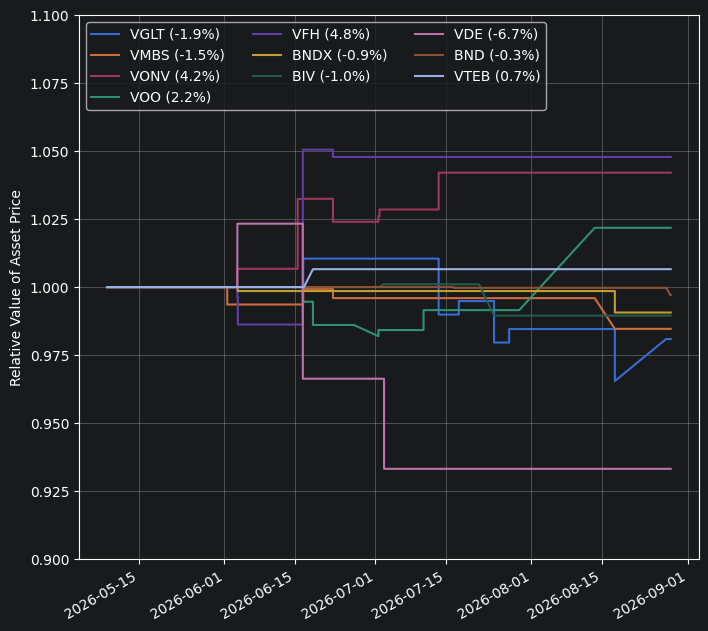

In [69]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [70]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
15,2026-08-28 11:42:14+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
21,2026-08-27 17:23:15+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
71,2026-07-26 14:27:29+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
86,2026-07-17 09:46:47+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
88,2026-07-16 22:04:59+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
811,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
812,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
813,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
814,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [71]:
data_deposits['net_amount'].sum()

np.float64(6535.96)

In [72]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,73.0,89.533699,47.248799,1.0,100.0,100.0,100.0,200.0


In [73]:
data_deposits['net_amount'].cumsum()

15      100.00
21      200.00
71      300.00
86      400.00
88      500.00
        ...   
811    6430.96
812    6440.96
813    6490.96
814    6510.96
815    6535.96
Name: net_amount, Length: 73, dtype: float64

In [74]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
815,2026-05-26 19:39:34+00:00,25.00
814,2026-05-26 21:58:29+00:00,45.00
813,2026-05-27 00:43:01+00:00,95.00
812,2026-05-27 00:56:05+00:00,105.00
811,2026-05-27 00:56:27+00:00,205.00
...,...,...
88,2026-07-16 22:04:59+00:00,6135.96
86,2026-07-17 09:46:47+00:00,6235.96
71,2026-07-26 14:27:29+00:00,6335.96
21,2026-08-27 17:23:15+00:00,6435.96


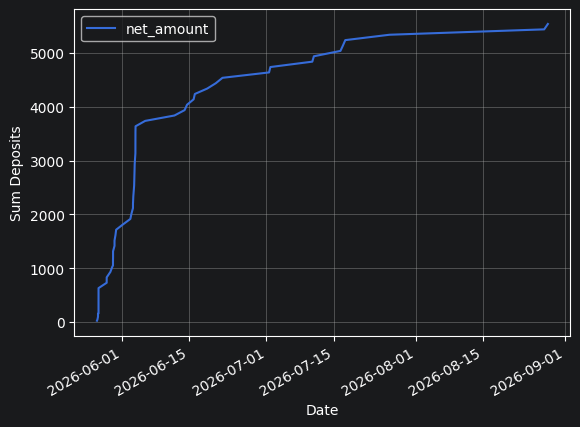

In [75]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [76]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.0
2026-05-26 21:58:29+00:00,0.0,20.0
2026-05-27 00:43:01+00:00,0.0,50.0
2026-05-27 00:56:05+00:00,0.0,10.0
2026-05-27 00:57:28+00:00,0.0,50.0
...,...,...
2026-07-16 22:04:59+00:00,100.0,0.0
2026-07-17 09:46:47+00:00,100.0,0.0
2026-07-26 14:27:29+00:00,100.0,0.0


In [77]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    5200.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64